In [6]:
# %matplotlib widget

from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from metpy import calc
from metpy.units import units
from shared.paths import load_paths

In [4]:
cd ..

/home/users/cornkle/pythonWorkspace/proj_CEH


/tmp/ipykernel_1966/571502713.py:62: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  abs_df[outvar], anom_df[outvar] = vpd_abs, vpd_abs - vpd_clim
/tmp/ipykernel_1966/571502713.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  abs_df[outvar], anom_df[outvar] = ef_abs * 100, (ef_abs - ef_clim) * 100
/tmp/ipykernel_1966/571502713.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.con

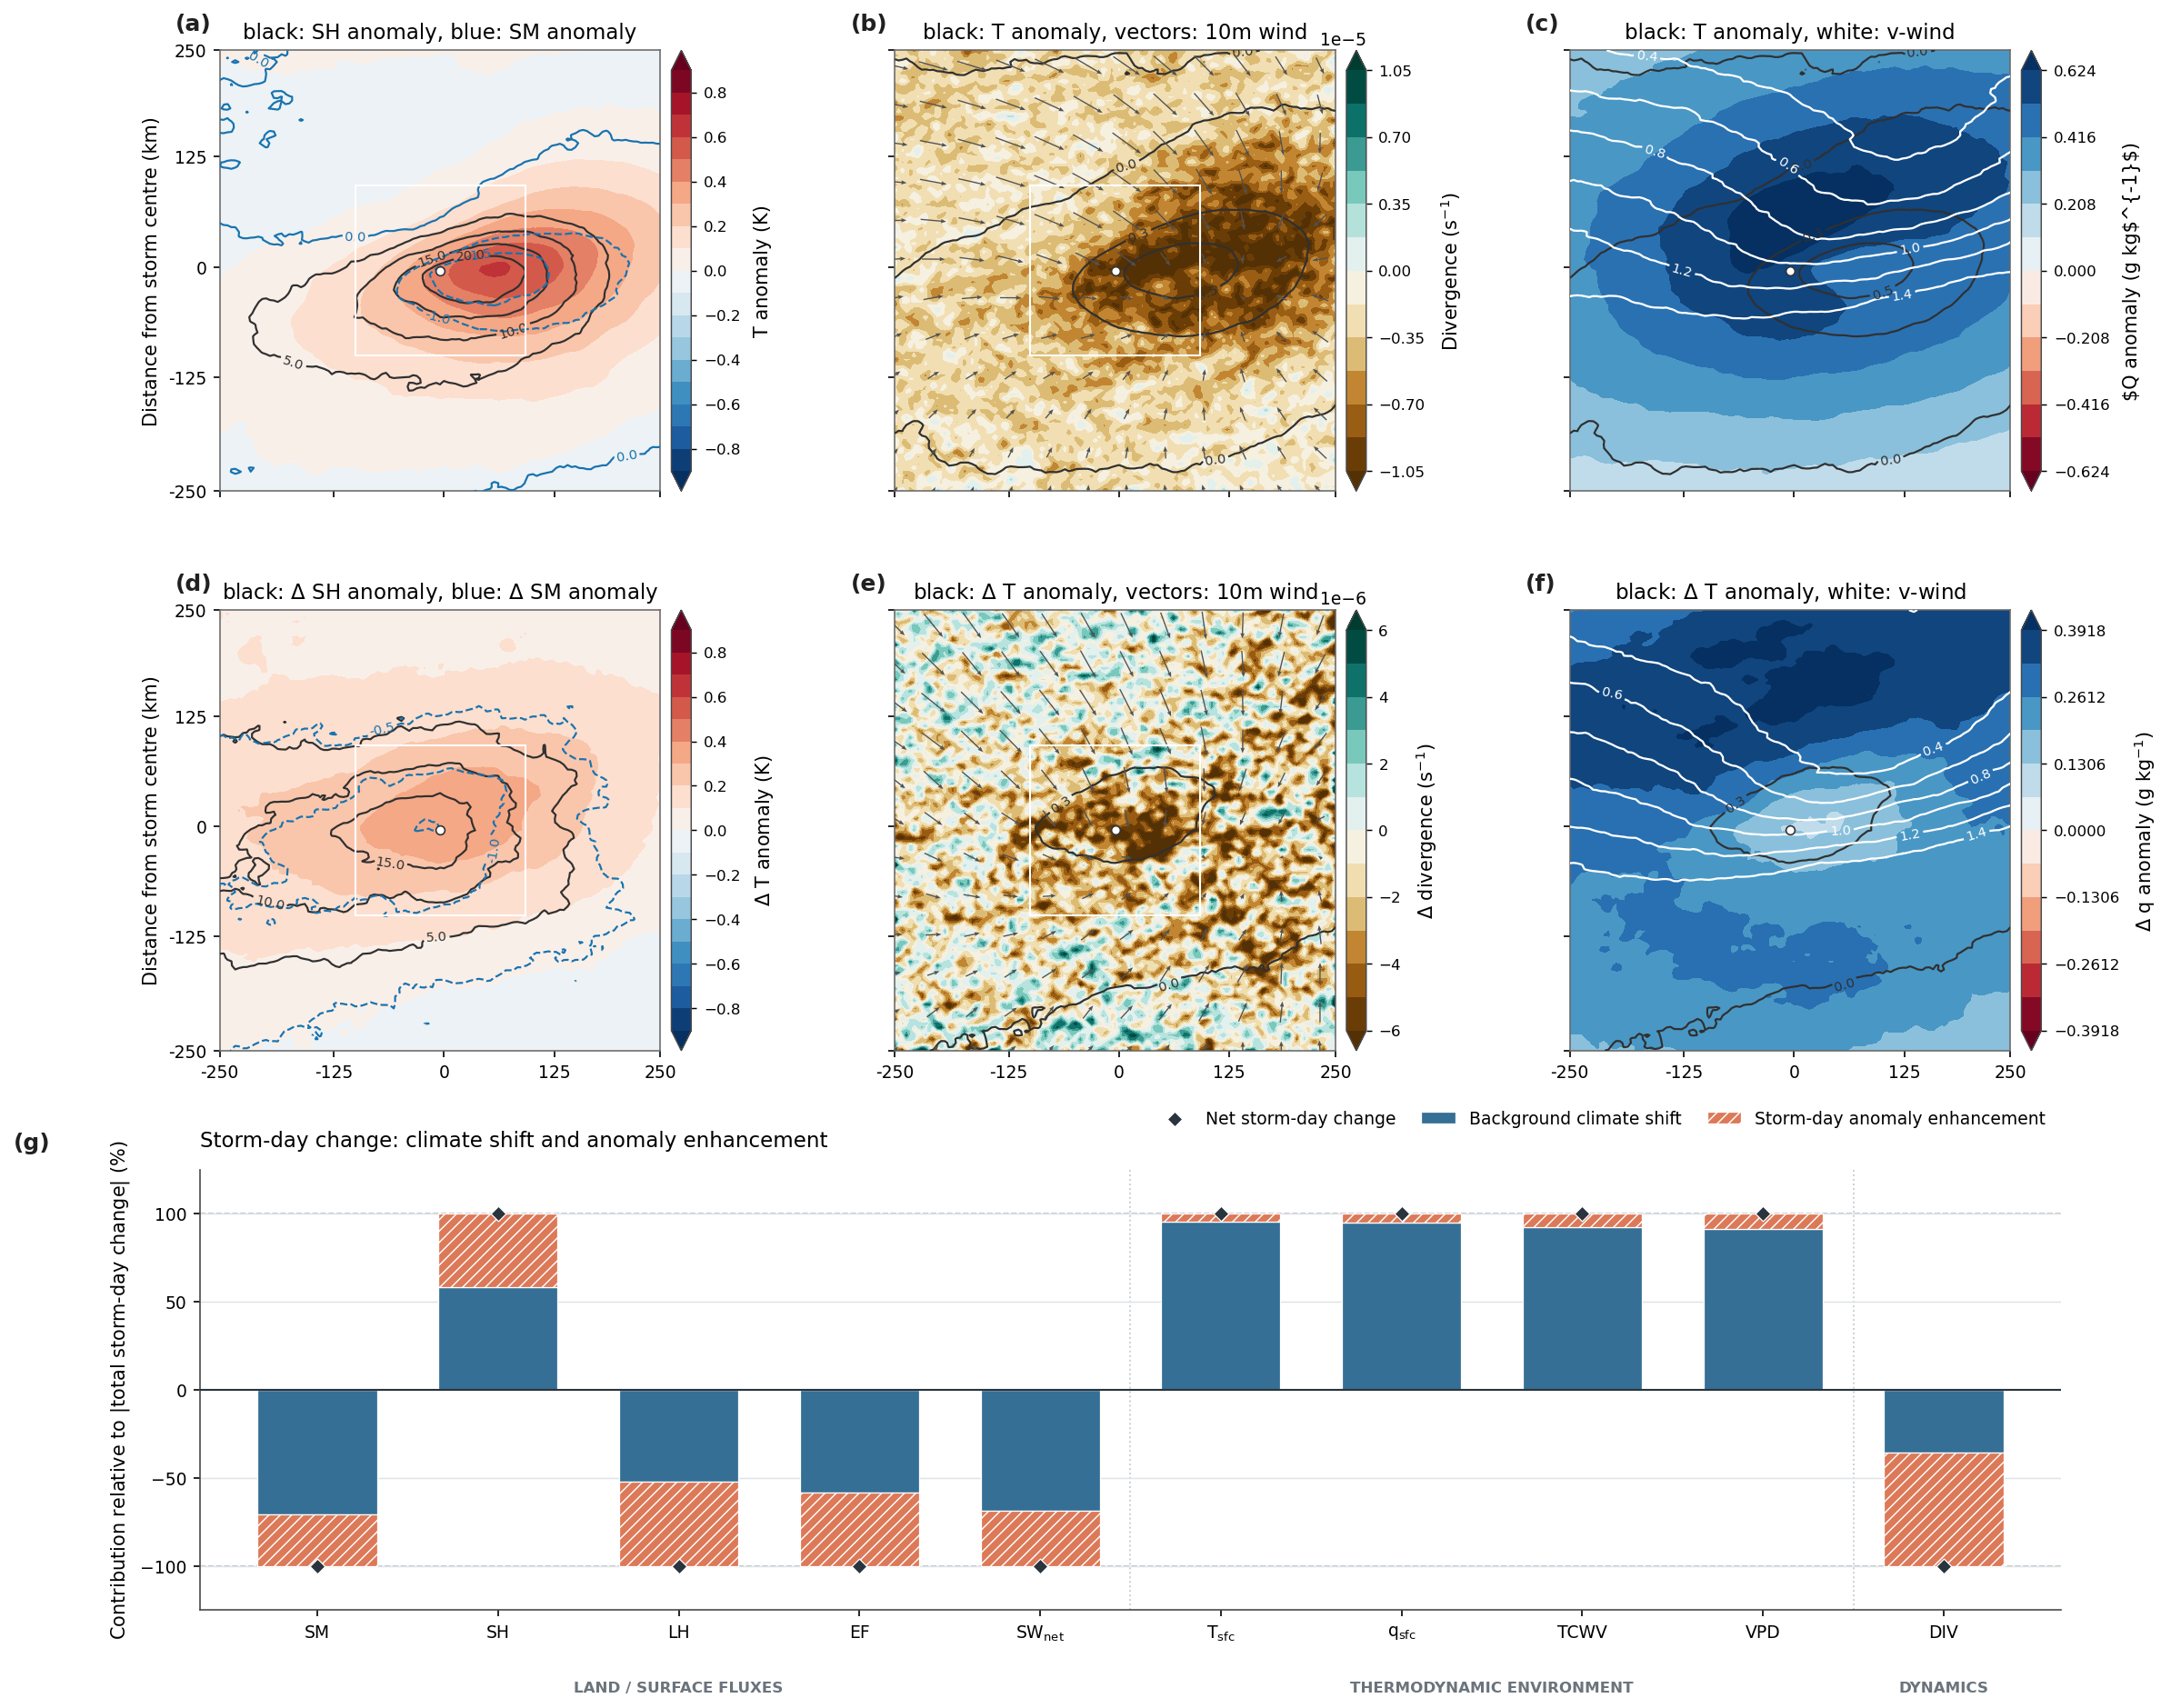

In [16]:
paths = load_paths()
cp4_path = Path('/gws/ssde/j25b/lmcs/cklein/CP_models/MCS_files/WAf/CP4_box_JASMIN/mean3h_v2')
table_path = Path(paths.cp4_2d) / 'CP4_box_JASMIN' / 'mean3h_v2' / 'tables'
output_file = 'cp4_combined_figure1.png'

hours = (17, 18)
dtag = '2deg'
pmax_threshold = 1.0
save_figure = True

mid = 57
box_half_width = 22
box = [mid - box_half_width, mid + box_half_width, mid - box_half_width, mid + box_half_width]
tick_positions = np.array([0, 58 - 57 / 2, 58, 58 + 57 / 2, 114])
tick_labels = [-250, -125, 0, 125, 250]

mpl.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white',
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'DejaVu Sans'], 'font.size': 10,
    'axes.titlesize': 11, 'axes.titleweight': 'normal', 'axes.labelsize': 10,
    'axes.linewidth': 0.8, 'axes.edgecolor': '#4a4a4a', 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'xtick.direction': 'out', 'ytick.direction': 'out', 'xtick.major.size': 3.5, 'ytick.major.size': 3.5,
    'legend.fontsize': 9, 'legend.frameon': False, 'mathtext.default': 'regular', 'hatch.linewidth': 0.7,
})


# ==================================================================================================
# DATA HELPERS
# ==================================================================================================

def load_composite(experiment, field_type):
    datasets = [xr.open_dataset(cp4_path / f'{experiment}_{field_type}_Jul-Sep_{hour}h_2d.nc') for hour in hours]
    return xr.concat(datasets, dim='_hour').mean('_hour', keep_attrs=True)


def calc_div(dataset, grid_spacing_m=4400):
    u = units.Quantity(dataset['u_srfc'].values, 'm/s')
    v = units.Quantity(dataset['v_srfc'].values, 'm/s')
    spacing = units.Quantity(grid_spacing_m, 'm')
    divergence = calc.divergence(u, v, dx=spacing, dy=spacing)
    output = dataset['sh'].copy(deep=True)
    output.name = 'divergence'
    output.attrs['units'] = 's-1'
    output.values = divergence.magnitude
    return output


def calc_vpd_from_t_q(t, q, p_hpa=925.0):
    t, q = np.asarray(t, dtype=float), np.asarray(q, dtype=float)
    q = np.where(q > 0.1, q / 1000.0, q)
    t_k = np.where(t < 150, t + 273.15, t)
    t_c = t_k - 273.15
    es = 6.112 * np.exp((17.67 * t_c) / (t_c + 243.5))
    e = q * p_hpa / (0.622 + (1 - 0.622) * q)
    return es - e


def add_vpd(abs_df, anom_df, suffix='2deg', p_hpa=925.0):
    tvar, qvar, outvar = f't_srfc_{suffix}', f'q_srfc_{suffix}', f'vpd_srfc_{suffix}'
    vpd_abs = calc_vpd_from_t_q(abs_df[tvar], abs_df[qvar], p_hpa=p_hpa)
    vpd_clim = calc_vpd_from_t_q(abs_df[tvar] - anom_df[tvar], abs_df[qvar] - anom_df[qvar], p_hpa=p_hpa)
    abs_df[outvar], anom_df[outvar] = vpd_abs, vpd_abs - vpd_clim
    return abs_df, anom_df


def calc_ef(lh, sh):
    lh, sh = np.asarray(lh, dtype=float), np.asarray(sh, dtype=float)
    denominator = lh + sh
    return np.where(np.isclose(denominator, 0) | np.isnan(denominator), np.nan, lh / denominator)


def add_ef(abs_df, anom_df, suffix='2deg'):
    lhvar, shvar, outvar = f'lh_{suffix}', f'sh_{suffix}', f'ef_{suffix}'
    ef_abs = calc_ef(abs_df[lhvar], abs_df[shvar])
    ef_clim = calc_ef(abs_df[lhvar] - anom_df[lhvar], abs_df[shvar] - anom_df[shvar])
    abs_df[outvar], anom_df[outvar] = ef_abs * 100, (ef_abs - ef_clim) * 100
    return abs_df, anom_df


def read_table(filename):
    return pd.read_csv(table_path / filename, index_col=0, low_memory=False).T


def convert_numeric_columns(df):
    df = df.copy()
    for column in df.columns:
        converted = pd.to_numeric(df[column], errors='coerce')
        if converted.notna().sum() == df[column].notna().sum():
            df[column] = converted
    return df


def match_tables(anom_df, abs_df, keys=('pmax', 'area', 'area_1mm')):
    keys = list(keys)
    common = pd.merge(anom_df[keys].drop_duplicates(), abs_df[keys].drop_duplicates(), on=keys, how='inner')
    anom_matched = anom_df.merge(common, on=keys, how='inner').reset_index(drop=True)
    abs_matched = abs_df.merge(common, on=keys, how='inner').reset_index(drop=True)
    return anom_matched, abs_matched


# ==================================================================================================
# LOAD COMPOSITES
# ==================================================================================================

da_hist_anom = load_composite('hist', 'anom')
da_fut_anom = load_composite('fut', 'anom')
da_hist = load_composite('hist', 'mean')
da_fut = load_composite('fut', 'mean')

hist_div = calc_div(da_hist)
fut_div = calc_div(da_fut)
delta_div = fut_div - hist_div

delta_t = da_fut_anom['t_srfc'] - da_hist_anom['t_srfc']
delta_q = (da_fut_anom['q_srfc'] - da_hist_anom['q_srfc']) * 1000
delta_sh = da_fut_anom['sh'] - da_hist_anom['sh']
delta_sm = da_fut_anom['SM'] - da_hist_anom['SM']
delta_u = da_fut_anom['u_srfc'] - da_hist_anom['u_srfc']
delta_v = da_fut_anom['v_srfc'] - da_hist_anom['v_srfc']


# ==================================================================================================
# LOAD TABLES AND CALCULATE PANEL (g)
# ==================================================================================================

lhist_orig = convert_numeric_columns(read_table('hist_mean_table_JASMIN_3hmeansVersion_rainMask_fullBox_ICAPE.csv'))
lfut_orig = convert_numeric_columns(read_table('fut_mean_table_JASMIN_3hmeansVersion_rainMask_fullBox_ICAPE.csv'))
lahist_orig = convert_numeric_columns(read_table('hist_anom_table_JASMIN_3hmeansVersion_rainMask_fullBox.csv'))
lafut_orig = convert_numeric_columns(read_table('fut_anom_table_JASMIN_3hmeansVersion_rainMask_fullBox.csv'))

lahist, lhist = match_tables(lahist_orig, lhist_orig)
lafut, lfut = match_tables(lafut_orig, lfut_orig)

lhist, lahist = add_vpd(lhist, lahist, suffix=dtag)
lfut, lafut = add_vpd(lfut, lafut, suffix=dtag)
lhist, lahist = add_ef(lhist, lahist, suffix=dtag)
lfut, lafut = add_ef(lfut, lafut, suffix=dtag)

lhist, lahist = lhist.loc[lhist['pmax'].ge(pmax_threshold)].reset_index(drop=True), lahist.loc[lahist['pmax'].ge(pmax_threshold)].reset_index(drop=True)
lfut, lafut = lfut.loc[lfut['pmax'].ge(pmax_threshold)].reset_index(drop=True), lafut.loc[lafut['pmax'].ge(pmax_threshold)].reset_index(drop=True)

variables = ['SM_2deg', 'sh_2deg', 'lh_2deg', 'ef_2deg', 'sw_net_2deg', 't_srfc_2deg', 'q_srfc_2deg', 'tcwv_2deg', 'vpd_srfc_2deg', 'div_2deg']
variable_labels = {'SM_2deg': 'SM', 'sh_2deg': 'SH', 'lh_2deg': 'LH', 'ef_2deg': 'EF', 'sw_net_2deg': r'SW$_{net}$',
                   't_srfc_2deg': r'T$_{sfc}$', 'q_srfc_2deg': r'q$_{sfc}$', 'tcwv_2deg': 'TCWV', 'vpd_srfc_2deg': 'VPD', 'div_2deg': 'DIV'}

climate_contribution, anomaly_contribution = [], []
for variable in variables:
    storm_hist, storm_fut = np.nanmean(lhist[variable]), np.nanmean(lfut[variable])
    anomaly_hist, anomaly_fut = np.nanmean(lahist[variable]), np.nanmean(lafut[variable])
    delta_storm = storm_fut - storm_hist
    delta_climate = (storm_fut - anomaly_fut) - (storm_hist - anomaly_hist)
    delta_anomaly = anomaly_fut - anomaly_hist
    climate_contribution.append(np.nan if np.isclose(delta_storm, 0) else delta_climate / abs(delta_storm) * 100)
    anomaly_contribution.append(np.nan if np.isclose(delta_storm, 0) else delta_anomaly / abs(delta_storm) * 100)

climate_contribution = np.asarray(climate_contribution)
anomaly_contribution = np.asarray(anomaly_contribution)
net_storm_day_change = np.sign(climate_contribution + anomaly_contribution) * 100


# ==================================================================================================
# PLOTTING HELPERS
# ==================================================================================================

def symmetric_levels(data, percentiles=(5, 95), n=13):
    values = np.asarray(data, dtype=float)
    values = values[np.isfinite(values)]
    lower, upper = np.nanpercentile(values, percentiles)
    limit = max(abs(lower), abs(upper))
    return np.linspace(-limit, limit, n)


def add_panel_label(ax, label):
    ax.text(-0.10, 1.035, f'({label})', transform=ax.transAxes, ha='left', va='bottom', fontsize=12,
            fontweight='bold', color='#202020', zorder=200, clip_on=False)


def add_colorbar(fig, ax, mappable, label):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='4.5%', pad=0.08)
    cbar = fig.colorbar(mappable, cax=cax)
    cbar.set_label(label, labelpad=7)
    cbar.ax.tick_params(length=3, width=0.7, labelsize=8)
    cbar.outline.set_linewidth(0.7)


def format_composite_axis(ax, show_ylabels=True, show_xlabels=False):
    ax.set_aspect('equal', adjustable='box')
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels if show_xlabels else [])
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_labels if show_ylabels else [])
    if show_ylabels:
        ax.set_ylabel('Distance from storm centre (km)')
    for spine in ax.spines.values():
        spine.set_color('#666666')
        spine.set_linewidth(0.75)


def add_box_and_centre(ax, draw_box=True):
    if draw_box:
        ax.add_patch(patches.Rectangle((box[0], box[2]), box[1] - box[0], box[3] - box[2], linewidth=1.0,
                                       edgecolor='white', facecolor='none', linestyle='-', zorder=100))
    ax.scatter(mid, mid, s=22, facecolor='white', edgecolor='#343434', linewidth=0.8, zorder=120)


def labelled_contour(ax, data, levels, color, label_color=None, linewidth=1.05):
    contour = ax.contour(np.asarray(data), levels=levels, colors=color, linewidths=linewidth, zorder=20)
    ax.clabel(contour, contour.levels, inline=True, inline_spacing=3, fontsize=7, fmt='%1.1f', colors=label_color or color)


def add_wind_vectors(ax, u, v, stride=10):
    u, v = np.asarray(u), np.asarray(v)
    y, x = np.arange(u.shape[0])[::stride], np.arange(u.shape[1])[::stride]
    return ax.quiver(x, y, u[::stride, ::stride], v[::stride, ::stride], color='#525252', width=0.0028,
                     headwidth=3.4, headlength=4.4, headaxislength=4.0, pivot='middle', zorder=30)


# ==================================================================================================
# COMBINED FIGURE
# ==================================================================================================

fig = plt.figure(figsize=(15, 13), dpi=150)
gs = GridSpec(3, 3, figure=fig, height_ratios=[1, 1, 1.0], hspace=0.27, wspace=0.32)
ax_a, ax_b, ax_c = [fig.add_subplot(gs[0, column]) for column in range(3)]
ax_d, ax_e, ax_f = [fig.add_subplot(gs[1, column]) for column in range(3)]
ax_g = fig.add_subplot(gs[2, :])

temperature_levels = np.arange(-0.9, 0.91, 0.1)
temperature_contours = [-0.9, -0.7, -0.5, -0.3, 0, 0.3, 0.5, 0.7, 0.9]
wind_contours = [-1.4, -1.2, -1.0, -0.8, -0.6, -0.4, 0, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4]
hist_divergence_levels = np.linspace(-1.05e-5, 1.05e-5, 13)
change_divergence_levels = np.linspace(-6e-6, 6e-6, 13)

m = ax_a.contourf(np.asarray(da_hist_anom['t_srfc']), levels=temperature_levels, cmap='RdBu_r', extend='both')
labelled_contour(ax_a, da_hist_anom['sh'], [5, 10, 15, 20], '#303030')
labelled_contour(ax_a, da_hist_anom['SM'], [-1.5, -1, 0, 1, 1.5], '#1773b0')
add_box_and_centre(ax_a); add_panel_label(ax_a, 'a'); ax_a.set_title('black: SH anomaly, blue: SM anomaly')
add_colorbar(fig, ax_a, m, 'T anomaly (K)')

m = ax_b.contourf(np.asarray(hist_div), levels=hist_divergence_levels, cmap='BrBG', extend='both')
labelled_contour(ax_b, da_hist_anom['t_srfc'], temperature_contours, '#303030')
add_wind_vectors(ax_b, da_hist_anom['u_srfc'], da_hist_anom['v_srfc'])
add_box_and_centre(ax_b); add_panel_label(ax_b, 'b'); ax_b.set_title('black: T anomaly, vectors: 10m wind')
add_colorbar(fig, ax_b, m, r'Divergence (s$^{-1}$)')

hist_q = da_hist_anom['q_srfc'] * 1000
m = ax_c.contourf(np.asarray(hist_q), levels=symmetric_levels(hist_q), cmap='RdBu', extend='both')
labelled_contour(ax_c, da_hist_anom['t_srfc'], temperature_contours, '#303030')
labelled_contour(ax_c, da_hist['v_srfc'], wind_contours, 'white', label_color='white', linewidth=1.1)
add_box_and_centre(ax_c, draw_box=False); add_panel_label(ax_c, 'c'); ax_c.set_title('black: T anomaly, white: v-wind')
add_colorbar(fig, ax_c, m, r'$Q anomaly (g kg$^{-1}$)')

m = ax_d.contourf(np.asarray(delta_t), levels=temperature_levels, cmap='RdBu_r', extend='both')
labelled_contour(ax_d, delta_sh, [5, 10, 15], '#303030')
labelled_contour(ax_d, delta_sm, [-1.5, -1, -0.5], '#1773b0')
add_box_and_centre(ax_d); add_panel_label(ax_d, 'd'); ax_d.set_title(r'black: $\Delta$ SH anomaly, blue: $\Delta$ SM anomaly')
add_colorbar(fig, ax_d, m, r'$\Delta$ T anomaly (K)')

m = ax_e.contourf(np.asarray(delta_div), levels=change_divergence_levels, cmap='BrBG', extend='both')
labelled_contour(ax_e, delta_t, temperature_contours, '#303030')
add_wind_vectors(ax_e, delta_u, delta_v)
add_box_and_centre(ax_e); add_panel_label(ax_e, 'e'); ax_e.set_title(r'black: $\Delta$ T anomaly, vectors: 10m wind')
add_colorbar(fig, ax_e, m, r'$\Delta$ divergence (s$^{-1}$)')

m = ax_f.contourf(np.asarray(delta_q), levels=symmetric_levels(delta_q), cmap='RdBu', extend='both')
labelled_contour(ax_f, delta_t, temperature_contours, '#303030')
labelled_contour(ax_f, da_fut['v_srfc'], wind_contours, 'white', label_color='white', linewidth=1.1)
add_box_and_centre(ax_f, draw_box=False); add_panel_label(ax_f, 'f'); ax_f.set_title(r'black: $\Delta$ T anomaly, white: v-wind')
add_colorbar(fig, ax_f, m, r'$\Delta$ q anomaly (g kg$^{-1}$)')

for column, ax in enumerate([ax_a, ax_b, ax_c]):
    format_composite_axis(ax, show_ylabels=(column == 0), show_xlabels=False)
for column, ax in enumerate([ax_d, ax_e, ax_f]):
    format_composite_axis(ax, show_ylabels=(column == 0), show_xlabels=True)

x = np.arange(len(variables))
clim_pos, clim_neg = np.where(climate_contribution > 0, climate_contribution, 0), np.where(climate_contribution < 0, climate_contribution, 0)
anom_pos, anom_neg = np.where(anomaly_contribution > 0, anomaly_contribution, 0), np.where(anomaly_contribution < 0, anomaly_contribution, 0)

ax_g.bar(x, clim_pos, width=0.66, color='#356f95', edgecolor='white', linewidth=0.6, label='Background climate shift', zorder=3)
ax_g.bar(x, clim_neg, width=0.66, color='#356f95', edgecolor='white', linewidth=0.6, zorder=3)
ax_g.bar(x, anom_pos, width=0.66, bottom=clim_pos, color='#dc7958', edgecolor='white', linewidth=0.6, hatch='////',
         label='Storm-day anomaly enhancement', zorder=3)
ax_g.bar(x, anom_neg, width=0.66, bottom=clim_neg, color='#dc7958', edgecolor='white', linewidth=0.6, hatch='////', zorder=3)
ax_g.scatter(x, net_storm_day_change, marker='D', s=32, color='#29343d', edgecolor='white', linewidth=0.6,
             label='Net storm-day change', zorder=6)

ax_g.axhline(0, color='#29343d', lw=1.0, zorder=4)
ax_g.axhline(100, color='#aeb6bc', lw=0.8, ls='--', zorder=1)
ax_g.axhline(-100, color='#aeb6bc', lw=0.8, ls='--', zorder=1)
ax_g.axvline(4.5, color='#c7cdd1', lw=0.9, ls=':', zorder=1)
ax_g.axvline(8.5, color='#c7cdd1', lw=0.9, ls=':', zorder=1)
ax_g.yaxis.grid(True, color='#dfe3e6', linewidth=0.7, zorder=0)
ax_g.set_xticks(x)
ax_g.set_xticklabels([variable_labels[v] for v in variables])
ax_g.set_xlim(-0.65, len(x) - 0.35)
ax_g.set_ylim(-125, 125)
ax_g.set_ylabel(r'Contribution relative to $|$total storm-day change$|$ (%)')
ax_g.set_title('Storm-day change: climate shift and anomaly enhancement', loc='left', pad=12)
ax_g.legend(loc='upper right', bbox_to_anchor=(1.0, 1.17), ncol=3, handlelength=2.0, columnspacing=1.5)
ax_g.spines['top'].set_visible(False)
ax_g.spines['right'].set_visible(False)
add_panel_label(ax_g, 'g')

ax_g.text(2.0, -0.16, 'LAND / SURFACE FLUXES', transform=ax_g.get_xaxis_transform(), ha='center', va='top', fontsize=8,
          fontweight='bold', color='#6b747c')
ax_g.text(6.5, -0.16, 'THERMODYNAMIC ENVIRONMENT', transform=ax_g.get_xaxis_transform(), ha='center', va='top', fontsize=8,
          fontweight='bold', color='#6b747c')
ax_g.text(9.0, -0.16, 'DYNAMICS', transform=ax_g.get_xaxis_transform(), ha='center', va='top', fontsize=8,
          fontweight='bold', color='#6b747c')

fig.subplots_adjust(left=0.065, right=0.975, bottom=0.085, top=0.965)

if save_figure:
    fig.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

